In [1]:
import pandas as pd

In [2]:
df =  pd.read_csv('netflix_customer_churn.csv')
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [3]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

In [4]:
#1 → Customer churned (cancelled)
#0 → Customer active

read and understands columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [6]:
df.drop('customer_id', axis=1 , inplace=True)

In [7]:
df.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'churned', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='object')

In [8]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [9]:
df.shape

(5000, 13)

In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [11]:
df.isnull().sum()

age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   object 
 2   subscription_type       5000 non-null   object 
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   object 
 6   device                  5000 non-null   object 
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   object 
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 507.9+ KB


here we put all Numerical columns in a list 

In [13]:
num_cols =  [
    'age' , 'watch_hours' , 'monthly_fee' , 'number_of_profiles' , 'avg_watch_time_per_day'
]

Mean (average) outliers se affect hota hai

Median realistic value deta hai

In [14]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [15]:
cat_cols = [
    'gender', 'subscription_type', 'region',
    'device', 'payment_method', 'favorite_genre'
]

In [16]:
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode())

In [17]:
df.dtypes

age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object


Target variable ML ke liye numeric

0 = Not churned

1 = Churned

In [18]:
df['churned'] = df['churned'].astype(int)

In [19]:
#remove invaild values 
df = df[df['watch_hours'] >= 0]
df = df[df['monthly_fee']>0]

Basic → 0               
Standard → 1  
Premium → 2 

female -> 0
male -> 1
other -> 2


ML models not understand text      
Simple and  fast     
sufficient for Churn prediction   

good work with Decision Tree / Random Forest 

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [21]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,2,0,14.73,29,0,3,8.99,1,3,1,0.49,0
1,47,2,2,0.70,19,2,2,13.99,1,3,5,0.03,6
2,27,0,2,16.32,10,1,3,13.99,0,1,2,1.48,3
3,53,2,1,4.51,12,4,3,17.99,1,1,2,0.35,4
4,56,2,2,1.89,13,0,2,13.99,1,1,2,0.13,0


StandardScaler

Model should not give too much importance to any one feature       
for Fair learning     
it must for Logistic Regression models

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])






In [23]:
df

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,0.461471,2,0,0.256425,29,0,3,-1.271341,1,3,-1.429965,-0.146895,0
1,0.203399,2,2,-0.911432,19,2,2,0.083051,1,3,1.395494,-0.322497,6
2,-1.086959,0,2,0.388777,10,1,3,0.083051,0,1,-0.723600,0.231031,3
3,0.590506,2,1,-0.594288,12,4,3,1.166565,1,1,-0.723600,-0.200339,4
4,0.784060,2,2,-0.812377,13,0,2,0.083051,1,1,-0.723600,-0.284322,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.603102,0,0,3.123211,11,2,0,-1.271341,0,0,0.689129,1.231198,3
4996,1.493757,0,0,-0.200563,2,3,0,-1.271341,0,4,-0.017235,0.841820,2
4997,1.429239,1,2,0.407922,49,5,0,0.083051,1,2,-0.723600,-0.207974,0
4998,0.977614,0,0,-0.210551,3,2,1,-1.271341,0,0,0.689129,0.536425,6


In [24]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   float64
 1   gender                  5000 non-null   int64  
 2   subscription_type       5000 non-null   int64  
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   int64  
 6   device                  5000 non-null   int64  
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   int64  
 10  number_of_profiles      5000 non-null   float64
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 507.9 KB


age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [25]:
df.to_csv("cleaned_netflix_data.csv", index=False)


Exploratory Data Analysis (EDA)
Observation the Data ,
Business Meaning 


Customer behavior samajhte hain      
Churn ke main reasons identify karte hain       
Decide karte hain kaunse features ML me important honge

In [26]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 




In [27]:
df = pd.read_csv('cleaned_netflix_data.csv')

print("Dataset Loaded Successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.info())


Dataset Loaded Successfully
Rows: 5000
Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   float64
 1   gender                  5000 non-null   int64  
 2   subscription_type       5000 non-null   int64  
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   int64  
 6   device                  5000 non-null   int64  
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   int64  
 10  number_of_profiles      5000 non-null   float64
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 507.

check customers churn and  customers active 

In [28]:

counts = df['churned'].value_counts()
counts


churned
1    2515
0    2485
Name: count, dtype: int64


for understand data here we use (countplot for categorical data) and (boxplot for numerical data)

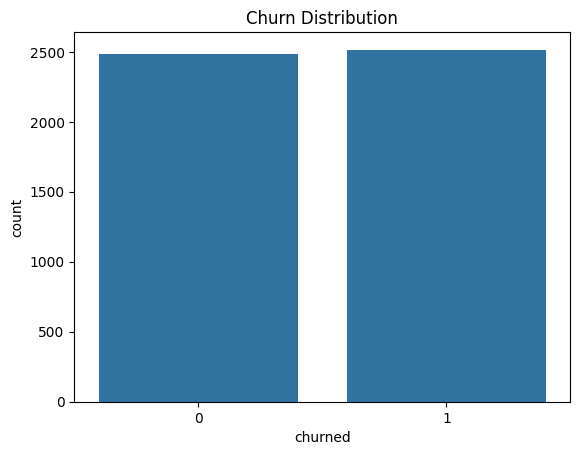

In [29]:
sns.countplot(x='churned' , data=df)
plt.title("Churn Distribution")
plt.show()


#The target variable analysis shows class imbalance which  common in real world churn data

Watch Hours vs Churn

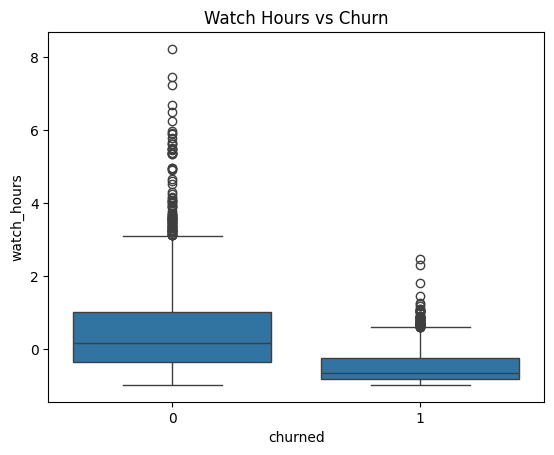

In [30]:
sns.boxplot(x='churned', y='watch_hours', data=df)
plt.title("Watch Hours vs Churn")
plt.show()


#Netflix ko low-engagement users ko re-engage karna chahiye.

Subscription Type vs Churn

which plan choose most 

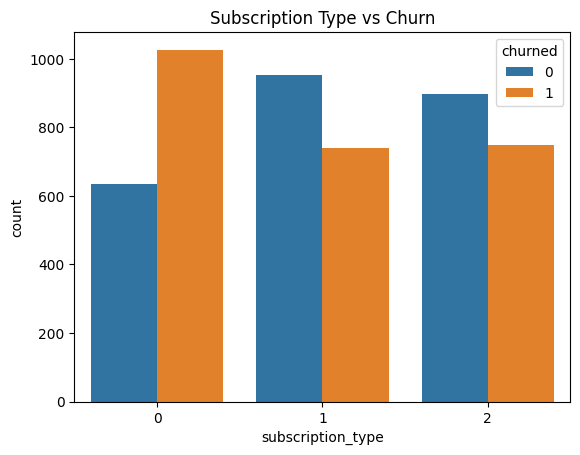

In [31]:
sns.countplot(x='subscription_type', hue='churned', data=df)
plt.title("Subscription Type vs Churn")
plt.show()


Last Login Days vs Churn

Inactive users churned

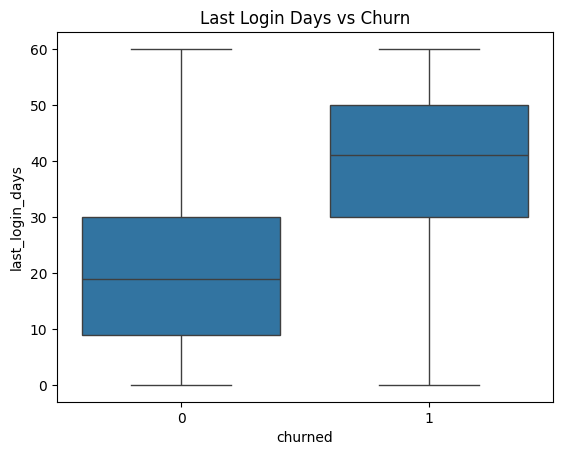

In [32]:
sns.boxplot(x='churned', y='last_login_days', data=df)
plt.title("Last Login Days vs Churn")
plt.show()



#Early reminders or notifications reduce the churn 

Monthly Fee vs Churn

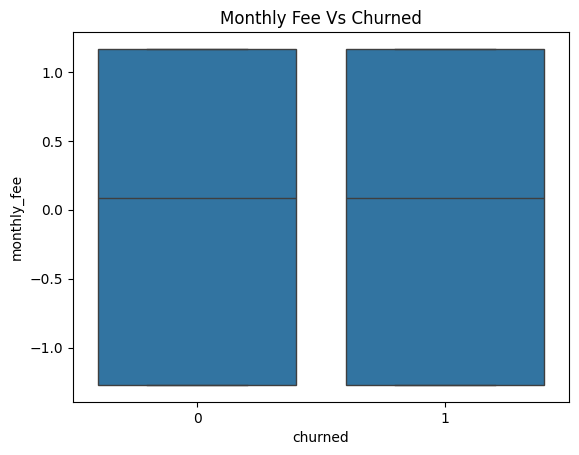

In [33]:
sns.boxplot(x= 'churned', y='monthly_fee' , data=df)
plt.title('Monthly Fee Vs Churned')
plt.show()


#Here not big effect monthly fee on churned 

Device vs Churn

is device effect on churn

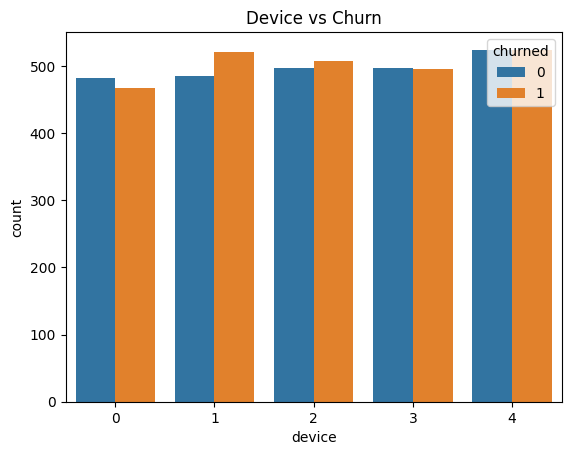

In [34]:
sns.countplot(hue='churned', x='device' ,  data=df)
plt.title("Device vs Churn")
plt.show()

Correlation Heatmap   

whice numerical features are strongly related to churn 


For Feature selection         
which variables are highly correlated with each other 


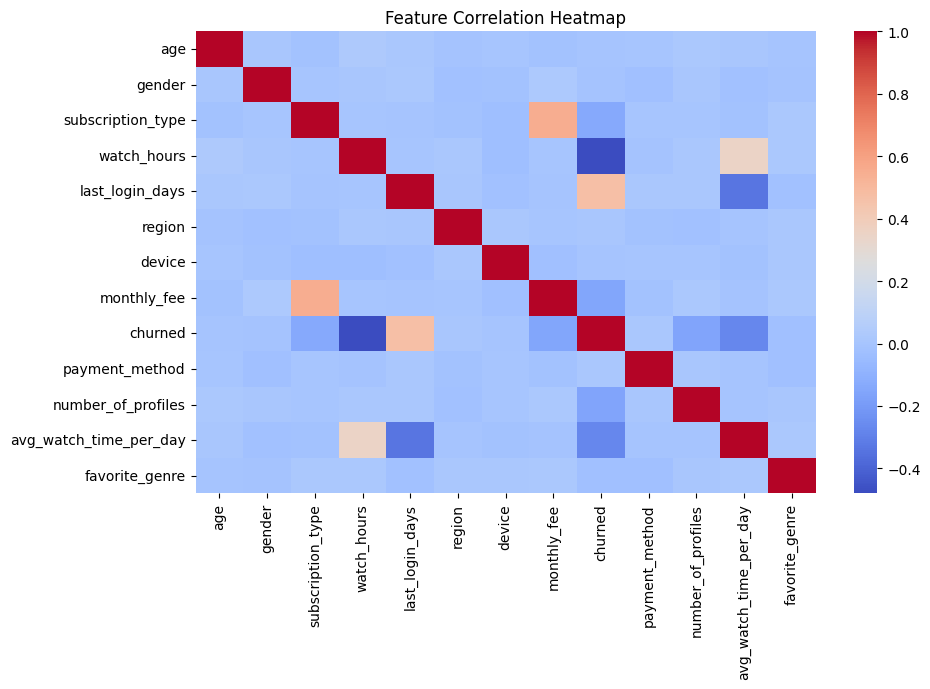

In [35]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


Feature Engineering

In [36]:
df.head()


,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,0.461471,2,0,0.256425,29,0,3,-1.271341,1,3,-1.429965,-0.146895,0
1,0.203399,2,2,-0.911432,19,2,2,0.083051,1,3,1.395494,-0.322497,6
2,-1.086959,0,2,0.388777,10,1,3,0.083051,0,1,-0.723600,0.231031,3
3,0.590506,2,1,-0.594288,12,4,3,1.166565,1,1,-0.723600,-0.200339,4
4,0.784060,2,2,-0.812377,13,0,2,0.083051,1,1,-0.723600,-0.284322,0


In [37]:
#show User interest level

df['engagement_score'] = (df['avg_watch_time_per_day'] * df['watch_hours'])

In [38]:
df['engagement_score']

0      -0.037667
1       0.293934
2       0.089819
3       0.119059
4       0.230977
          ...   
4995    3.845292
4996   -0.168838
4997   -0.084837
4998   -0.112945
4999    0.250115
Name: engagement_score, Length: 5000, dtype: float64

inactive_flag identifies inactive users, which strongly helps predict churn.

In [39]:
df['inactive_flag'] = df['last_login_days'].apply(lambda x : 1 if x > 30 else 0)

In [40]:
df['high_price_flag'] = df['monthly_fee'].apply(
    lambda x: 1 if x > df['monthly_fee'].median() else 0
)


In [41]:
df.drop(['avg_watch_time_per_day'], axis=1, inplace=True)


In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 5000 non-null   float64
 1   gender              5000 non-null   int64  
 2   subscription_type   5000 non-null   int64  
 3   watch_hours         5000 non-null   float64
 4   last_login_days     5000 non-null   int64  
 5   region              5000 non-null   int64  
 6   device              5000 non-null   int64  
 7   monthly_fee         5000 non-null   float64
 8   churned             5000 non-null   int64  
 9   payment_method      5000 non-null   int64  
 10  number_of_profiles  5000 non-null   float64
 11  favorite_genre      5000 non-null   int64  
 12  engagement_score    5000 non-null   float64
 13  inactive_flag       5000 non-null   int64  
 14  high_price_flag     5000 non-null   int64  
dtypes: float64(5), int64(10)
memory usage: 586.1 KB


Features (X) & Target (y)

In [43]:
x = df.drop('churned' , axis =1)
y = df['churned']

In [44]:
from sklearn.model_selection import  train_test_split
x_train , x_test ,y_train , y_test = train_test_split(x ,y , test_size=0.2 , random_state=42 , stratify=y)

In [45]:
x_train.shape ,x_test.shape

((4000, 14), (1000, 14))

In [46]:
y_train.shape

(4000,)

In [47]:
cols =  [
    'age' , 'watch_hours' , 'monthly_fee' , 'number_of_profiles'  ,'engagement_score' ,'inactive_flag','payment_method','churned'
]


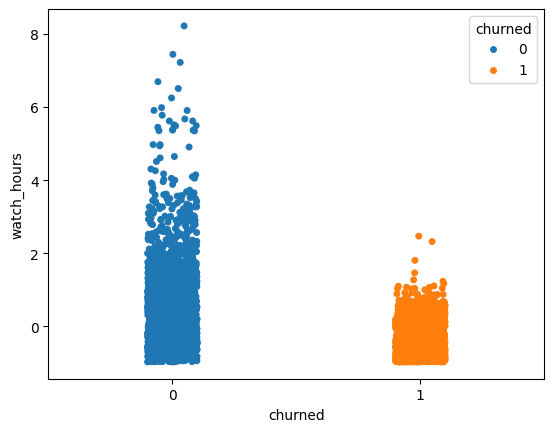

In [48]:
sns.stripplot(data=df, x='churned', y='watch_hours', hue='churned', jitter=True)
plt.show()


In [49]:
y_train.value_counts(normalize=True)

churned
1    0.503
0    0.497
Name: proportion, dtype: float64

ML Model Training”

Logistic Regression
Decision Tree
Random Forest

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [51]:
print(y_train.head())
print(y_train.unique())
print(y_train.dtype)

1310    0
2139    1
3293    1
134     1
2619    0
Name: churned, dtype: int64
[0 1]
int64


In [52]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [53]:
log_pred = log_model.predict(x_test)
accuracy_score(y_test,log_pred)

0.892

In [54]:
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
dt_pred = dt_model.predict(x_test)
accuracy_score(y_test,dt_pred)

0.972

In [56]:
rf_model = RandomForestClassifier(n_estimators=500)
rf_model.fit(x_train , y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
rf_pred = rf_model.predict(x_test)
accuracy_score(y_test,rf_pred)

0.969

In [58]:
ref_prob = rf_model.predict_proba(x_test)[:,1]


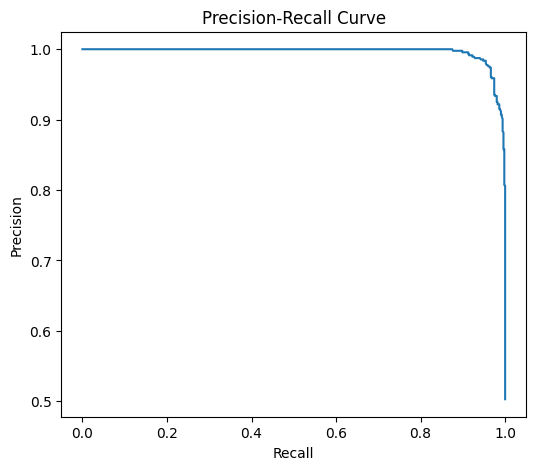

In [59]:
from sklearn.metrics import precision_recall_curve
precision,recall,threshold = precision_recall_curve(y_test , ref_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

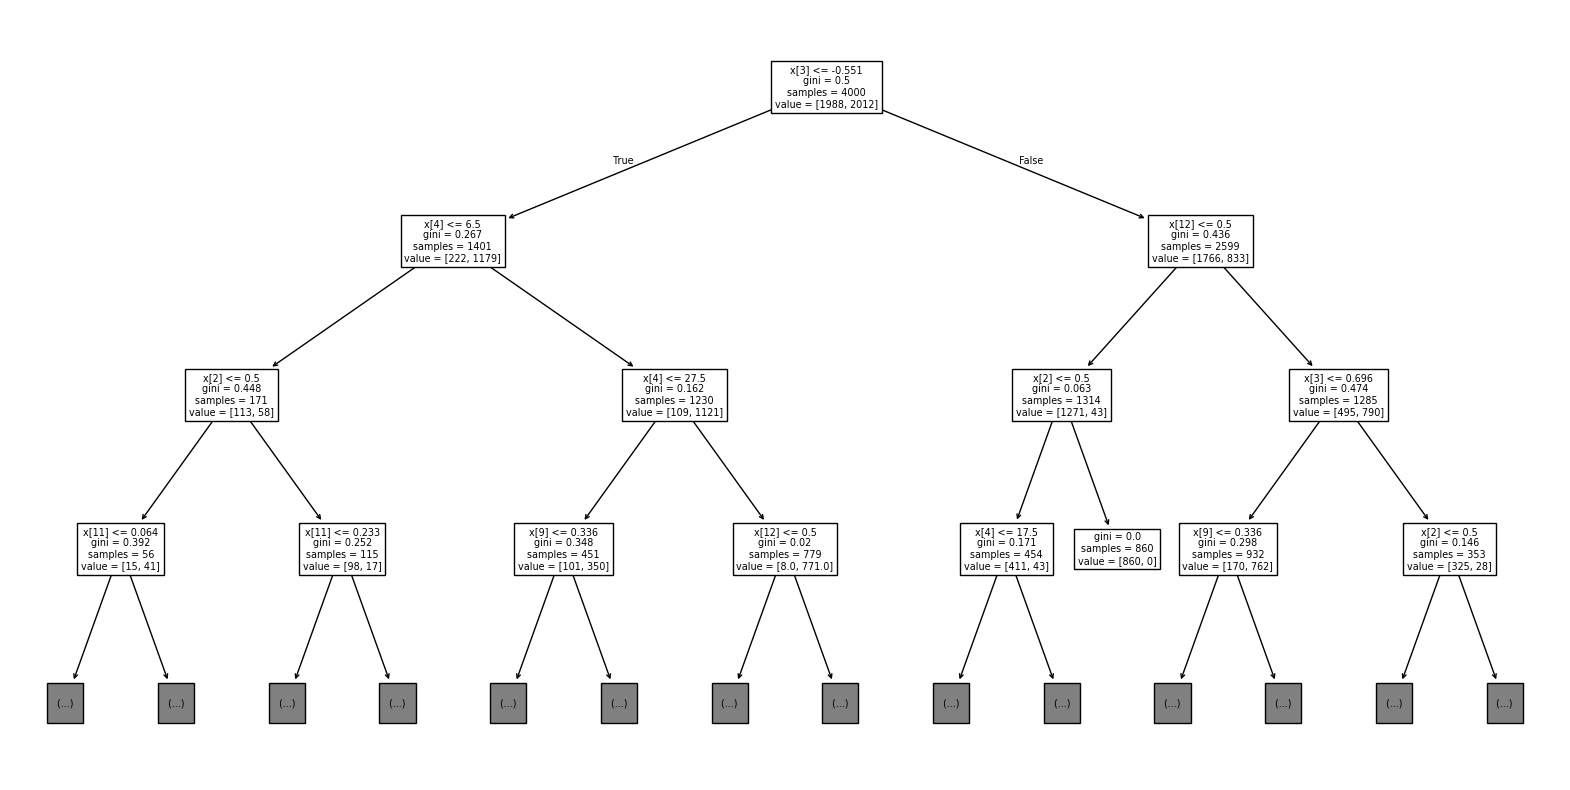

In [60]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_model,max_depth=3)
plt.show()

In [61]:
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , confusion_matrix , classification_report

In [62]:
confusion_matrix(y_test , log_pred)

array([[452,  45],
       [ 63, 440]])

In [63]:
confusion_matrix(y_test, dt_pred)

array([[480,  17],
       [ 11, 492]])

In [64]:
confusion_matrix(y_test , rf_pred)

array([[489,   8],
       [ 23, 480]])

Classification Report

In [65]:
print(classification_report(y_test , log_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       497
           1       0.91      0.87      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



In [66]:
print('DecisionTree')
print(classification_report(y_test , dt_pred))
print('RandomForest')
print(classification_report(y_test , rf_pred))

DecisionTree
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       497
           1       0.97      0.98      0.97       503

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000

RandomForest
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       497
           1       0.98      0.95      0.97       503

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [67]:
models = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, y_pred in models.items():
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))



Logistic Regression
Accuracy : 0.892
Precision: 0.9072164948453608
Recall   : 0.8747514910536779
F1 Score : 0.8906882591093117

Decision Tree
Accuracy : 0.972
Precision: 0.9666011787819253
Recall   : 0.9781312127236581
F1 Score : 0.9723320158102767

Random Forest
Accuracy : 0.969
Precision: 0.9836065573770492
Recall   : 0.9542743538767395
F1 Score : 0.9687184661957619


In [68]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance


,Feature,Importance
3,watch_hours,0.329100
4,last_login_days,0.172031
11,engagement_score,0.145102
12,inactive_flag,0.127319
9,number_of_profiles,0.066529
8,payment_method,0.034749
0,age,0.028187
7,monthly_fee,0.019185
2,subscription_type,0.018976
10,favorite_genre,0.016472


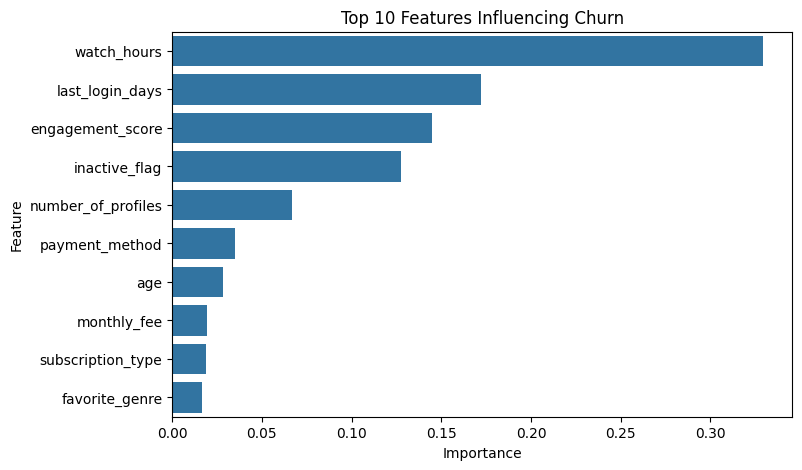

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top 10 Features Influencing Churn")
plt.show()
